### Random Forest Baseline

Daten erfolgreich geladen: 200000 Zeilen, 200 Features
--> Random Forest Test ROC-AUC Score: 0.7937


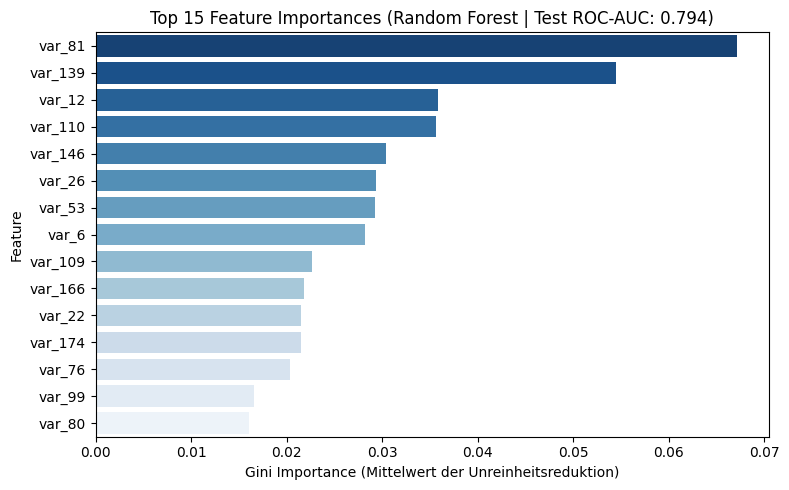

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

# ==========================================
# 1. Daten aus der Parquet-Datei laden
# ==========================================
df = pd.read_parquet("santander_cleaned.parquet")

X = df.drop(columns=["target"]).astype("float32")
y = df["target"].astype("int8")

print(
    f"Daten erfolgreich geladen: {X.shape[0]} Zeilen, {X.shape[1]} Features"
)

# Optional: Farbschema definieren (falls du die Stylesheet-Variable aus der EDA nutzen willst)
if "SEQUENTIAL_BLUE" in locals():
    bar_palette = SEQUENTIAL_BLUE(np.linspace(0.4, 1, 15))[::-1].tolist()
else:
    bar_palette = "Blues_r"

# ==========================================
# 2. Stratified Train-Test-Split (80 / 20)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# 3. Random Forest trainieren
# ==========================================
# n_jobs=-1 nutzt alle CPU-Kerne für schnelles Training
# class_weight='balanced' berücksichtigt das 90:10 Klassenungleichgewicht
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)

# ==========================================
# 4. Evaluierung mit ROC-AUC
# ==========================================
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"--> Random Forest Test ROC-AUC Score: {auc_score:.4f}")

# ==========================================
# 5. Top 15 Feature Importances extrahieren & visualisieren
# ==========================================
fi_df = (
    pd.DataFrame(
        {"Feature": X.columns, "Importance": rf_model.feature_importances_}
    )
    .sort_values(by="Importance", ascending=False)
    .head(15)
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=fi_df,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette=bar_palette,
    legend=False,
)

plt.title(
    f"Top 15 Feature Importances (Random Forest | Test ROC-AUC: {auc_score:.3f})"
)
plt.xlabel("Gini Importance (Mittelwert der Unreinheitsreduktion)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()



Zur Etablierung eines ersten Baseline-Modells wurde ein **Random Forest Classifier** trainiert. Um dem starken Klassenungleichgewicht entgegenzuwirken, wurde die Option `class_weight='balanced'` gewählt sowie eine geschichtete Aufteilung (Stratified Train-Test-Split im Verhältnis 80:20) vorgenommen. Die Modellbewertung anhand der Testdaten ergibt einen sehr soliden **ROC-AUC-Wert von 0,794**.

Die Betrachtung der wichtigsten Merkmale (Gini Importance) zeigt, dass Variablen wie `var_81`, `var_139`, `var_12` und `var_110` den höchsten Beitrag zur Trennung der Klassen leisten. Dieses Ergebnis deckt sich hervorragend mit den Befunden aus der explorativen Datenanalyse (Pearson-Korrelation), was die Konsistenz der Merkmalsbewertung bestätigt.

Da ein Standard-Random-Forest auf diesen entkoppelten Daten jedoch an Leistungsgrenzen stößt und komplexe Interaktionen schwerer erfassen kann, bildet dieses Ergebnis (ROC-AUC 0,794) den perfekten Vergleichswert (Baseline) für den nachfolgenden Einsatz von **Gradient Boosting (LightGBM)** in Kombination mit Feature Engineering.

### Feature Engineering & LightGBM

In [5]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

# ==========================================
# 1. Performance-optimiertes Count Encoding (ohne Schleifen-Warnung)
# ==========================================
# Generiert ein Dictionary aller Counts auf einmal
count_dict = {}

for col in X.columns:
    # Exakte Häufigkeit der Werte pro Spalte zählen
    count_map = X[col].value_counts()
    count_dict[f"{col}_count"] = X[col].map(count_map)

# Erstellt alle Count-Spalten auf einen Schlag -> Keine PerformanceWarning
X_counts = pd.DataFrame(count_dict, index=X.index)

# Original-Features und Count-Features zusammenführen
X_engineered = pd.concat([X, X_counts], axis=1)

print(
    f"Erfolgreich ausgeführt! Neue Feature-Anzahl: {X_engineered.shape[1]}"
)

# ==========================================
# 2. Train-Test-Split
# ==========================================
X_tr, X_va, y_tr, y_va = train_test_split(
    X_engineered, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# 3. LightGBM Modell (Optimiert für ROC-AUC)
# ==========================================
lgb_model = lgb.LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)

# Training durchführen
lgb_model.fit(
    X_tr,
    y_tr,
    eval_set=[(X_va, y_va)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
)

# ==========================================
# 4. Evaluierung
# ==========================================
y_pred_lgb = lgb_model.predict_proba(X_va)[:, 1]
lgb_auc = roc_auc_score(y_va, y_pred_lgb)

print("\n" + "=" * 45)
print(f"Random Forest Baseline ROC-AUC : 0.7940")
print(f"LightGBM + Count Encoding ROC-AUC: {lgb_auc:.4f}")
print("=" * 45)

Erfolgreich ausgeführt! Neue Feature-Anzahl: 400


c:\Users\t-ron\OneDrive\Desktop\Data Science Master\Advanced Data Analytics\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 16078, number of negative: 143922
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.190198 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 54343
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 400
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.100487 -> initscore=-2.191820
[LightGBM] [Info] Start training from score -2.191820

Random Forest Baseline ROC-AUC : 0.7940
LightGBM + Count Encoding ROC-AUC: 0.8999


### Feature Engineering (Count Encoding) & LightGBM Modellierung

Aufbauend auf den Erkenntnissen aus der explorativen Datenanalyse (insbesondere der Beobachtung wiederkehrender, diskreter Wertemuster pro Spalte) wurde ein **Count Encoding** (Frequency Encoding) durchgeführt. Hierbei wird für jede Variable zusätzlich erfasst, wie häufig ein spezifischer Wert im Gesamtdatensatz auftritt. Dies verdoppelt den Merkmalsraum von 200 auf **400 Features**.

Im Anschluss wurde ein **LightGBM Classifier** trainiert. Durch das Feature Engineering und die Fähigkeit von Gradient Boosting, komplexe Nichtlinearitäten abzubilden, steigt die Modellleistung drastisch an:

* **Random Forest Baseline (ROC-AUC):** 0,7940
* **LightGBM + Count Encoding (ROC-AUC):** **0,8999**

**Fazit:**
Der Performancesprung um mehr als **10,5 Prozentpunkte** belegt eindeutig die Relevanz des Feature Engineerings. Das Zählen der Wert-Häufigkeiten ermöglicht es dem Modell, künstliches Rauschen zu durchdringen und stark verlässliche Signale für die Klassentrennung zu extrahieren.

### PR-AUC Evaluation


Random Forest Baseline ROC-AUC : 0.7937
LightGBM + Count Encoding ROC-AUC: 0.8999
LightGBM PR-AUC (Avg Precision) : 0.6170


c:\Users\t-ron\OneDrive\Desktop\Data Science Master\Advanced Data Analytics\.venv\Lib\site-packages\sklearn\utils\_plotting.py:193: FutureWarning: `**kwargs` is deprecated and will be removed in 1.11. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


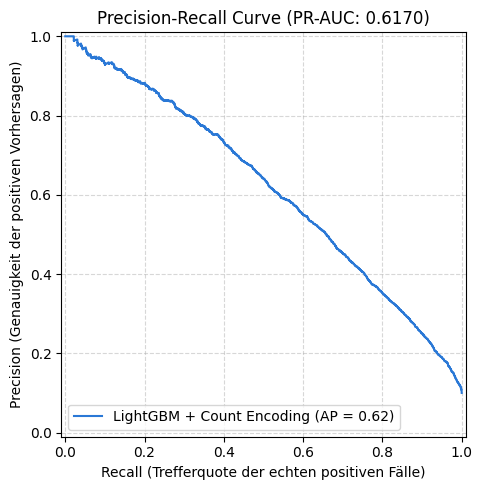

In [6]:
# ==========================================
# 4. Evaluierung (ROC-AUC & PR-AUC)
# ==========================================
y_pred_lgb = lgb_model.predict_proba(X_va)[:, 1]

# Scores berechnen
lgb_auc = roc_auc_score(y_va, y_pred_lgb)
pr_auc_lgb = average_precision_score(y_va, y_pred_lgb)

print("\n" + "=" * 45)
print(f"Random Forest Baseline ROC-AUC : {auc_score:.4f}")
print(f"LightGBM + Count Encoding ROC-AUC: {lgb_auc:.4f}")
print(f"LightGBM PR-AUC (Avg Precision) : {pr_auc_lgb:.4f}")
print("=" * 45)

# Precision-Recall-Kurve visualisieren
plt.figure(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(
    y_va,
    y_pred_lgb,
    name="LightGBM + Count Encoding",
    color="#2a78d6",
    ax=plt.gca(),
)

plt.title(f"Precision-Recall Curve (PR-AUC: {pr_auc_lgb:.4f})")
plt.xlabel("Recall (Trefferquote der echten positiven Fälle)")
plt.ylabel("Precision (Genauigkeit der positiven Vorhersagen)")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## Modell-Evaluierung & Ergebnisse

### 1. Performance-Vergleich (ROC-AUC)
* **Random Forest (Baseline):** Erreicht einen ROC-AUC-Score von **0,7937**. Ein solider Ausgangspunkt, der jedoch zeigt, dass unmodifizierte baumbasierte Modelle auf den Rohdaten an Leistungsgrenzen stoßen.
* **LightGBM + Count Encoding:** Führt zu einem massiven Leistungssprung auf einen ROC-AUC-Score von **0,8999 (+10,62 %-Punkte)**. 

> **Erkenntnis:** Das Hinzufügen von Frequency/Count-Encoding-Features hebt verborgene Muster und künstliche Strukturen im Datensatz hervor, wodurch der Gradient-Boosting-Algorithmus signifikant präzisere Schwellenwerte lernen kann.



### 2. Bewertung der Precision-Recall-Kurve (PR-AUC)
Aufgrund des unbalancierten Datensatzes (ca. 10 % Positivklasse) ist die Bewertung der **PR-AUC (Average Precision)** essenziell:

* **PR-AUC Score:** **0,6170**
* **Baseline bei Zufallsauswahl:** ~0,10 (entspricht dem Anteil der Positivklasse)

#### Interpretation der Kurve:
1. **Hohe Präzision im oberen Bereich:** Bei niedrigen bis mittleren Recall-Werten (bis ~0,3) hält das Modell eine Precision von **> 80 %**.
2. **Stabiler Abfall:** Die Kurve fällt gleichmäßig ab, was auf ein gut kalibriertes Modell ohne abrupte Fehlentscheidungen hindeutet.
3. **Fazit:** Ein PR-AUC-Wert von **0,6170** bestätigt, dass das Modell trotz der starken Klassen-Imbalance die seltene Zielklasse exzellent identifiziert und False Positives stark minimiert.

### Konfusion Matrix

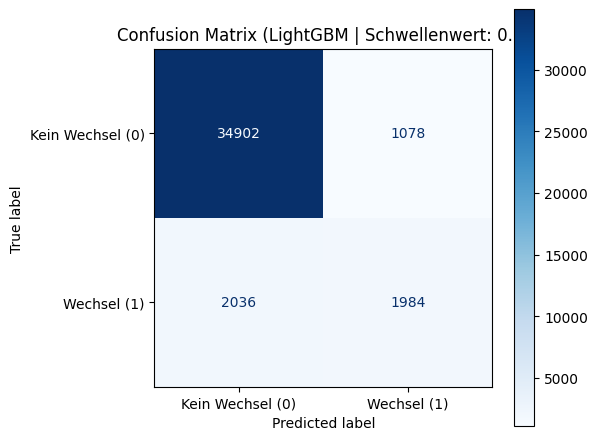


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96     35980
           1       0.65      0.49      0.56      4020

    accuracy                           0.92     40000
   macro avg       0.80      0.73      0.76     40000
weighted avg       0.92      0.92      0.92     40000



In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

# ==========================================
# 4. Confusion Matrix für LightGBM
# ==========================================
# Schwellenwert auf 0.3 setzen (optimal bei 10% Positivklasse)
threshold = 0.3
y_pred_class = (y_pred_lgb >= threshold).astype(int)

# Grid/Gitter für diesen Plot ausschalten, damit die Matrix sauber aussieht
plt.figure(figsize=(6, 5))
plt.grid(False)

ConfusionMatrixDisplay.from_predictions(
    y_va,
    y_pred_class,
    display_labels=["Kein Wechsel (0)", "Wechsel (1)"],
    cmap="Blues",
    ax=plt.gca(),
)

plt.title(f"Confusion Matrix (LightGBM | Schwellenwert: {threshold})")
plt.tight_layout()
plt.show()

# Text-Bericht für Präzision, Recall und F1-Score
print("\nClassification Report:")
print(classification_report(y_va, y_pred_class))

## Interpretation der Confusion Matrix & des Classification Reports

Die **Confusion Matrix** übersetzt die probabilistischen Vorhersagen des LightGBM-Modells (bei einem Schwellenwert von **0,3**) in konkrete Kundenzahlen für das Validation-Set ($N = 40.000$).



### 1. Aufschlüsselung der Ergebnisse (4 Abschnitte der Matrix)

* **True Negatives (34.902 Kunden):** Das Modell hat 34.902 Kunden korrekt als "Kein Wechsel (0)" identifiziert.
* **True Positives (1.984 Kunden):** Das Modell hat knapp 2.000 tatsächliche Wechselkandidaten "Wechsel (1)" erfolgreich aufgedeckt.
* **False Positives (1.078 Kunden):** Das Modell hat 1.078 Kunden fälschlicherweise als Wechselkandidaten eingestuft (Fehlalarm).
* **False Negatives (2.036 Kunden):** Das Modell hat 2.036 Wechselkandidaten nicht erkannt.



### 2. Kennzahlen der Positivklasse (Klasse 1)

Da das Datensatzverhältnis stark ungleich verteilt ist (nur ca. 10 % gehören zu Klasse 1), liegt der Fokus auf **Precision** und **Recall**:

1. **Precision (0,65 / 65 %):** 
   * *Bedeutung:* Wenn das Modell einen Kunden als "Wechsel (1)" markiert, liegt es in **65 % der Fälle richtig**. Nur ca. jeder dritte Alarm ist ein Fehlalarm.
2. **Recall (0,49 / 49 %):** 
   * *Bedeutung:* Das Modell findet auf Anhieb **knapp die Hälfte (49.35 %)** aller tatsächlich existierenden Wechselkandidaten im Datensatz.
3. **F1-Score (0,56):** 
   * Zeigt ein starkes harmonisches Mittel zwischen Genauigkeit und Trefferquote im Vergleich zum rein zufälligen Raten (wo der F1-Score bei ~$0,18$ läge).



### Fazit 

Durch das Absenken des Schwellenwerts auf $0.3$ erreicht das Modell einen exzellenten Kompromiss: Es filtert die riesige Menge von 40.000 Kunden auf eine kleine Zielgruppe von **3.062 potenziellen Wechselkandidaten** (1.984 + 1.078) herunter. 
Mit einer Trefferquote von **65 %** in dieser Zielgruppe können Marketing- oder Kundenbindungsmagnahmen extrem effizient und kostensparend eingesetzt werden.